In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv('sft_data_with_safe_and_unsafe_prompts.csv')

In [3]:
data = data.dropna(subset=['prompt', 'is_unsafe_prompt', 'is_unsafe_response','response'])
data=data[data['is_unsafe_prompt']==1]
data_chosen=data[data['is_unsafe_response']==False]
data_rejected = data[data['is_unsafe_response'] == True]

In [4]:
data_chosen=data_chosen.drop_duplicates(subset='prompt')
data_chosen = data_chosen.drop_duplicates(subset='response')
data_rejected = data_rejected.drop_duplicates(subset='prompt')
data_rejected = data_rejected.drop_duplicates(subset='response')

In [5]:
print(data_chosen.info())
print(data_rejected.info())
data_dpo_classifier=pd.concat([data_chosen,data_rejected])
data_dpo_classifier.to_csv('data_dpo_classifier.csv')

<class 'pandas.DataFrame'>
Index: 8970 entries, 3 to 45535
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   prompt              8970 non-null   str  
 1   is_unsafe_prompt    8970 non-null   int64
 2   response            8970 non-null   str  
 3   is_unsafe_response  8970 non-null   int64
 4   from_dataset        8970 non-null   str  
dtypes: int64(2), str(3)
memory usage: 8.6 MB
None
<class 'pandas.DataFrame'>
Index: 9735 entries, 2 to 48023
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   prompt              9735 non-null   str  
 1   is_unsafe_prompt    9735 non-null   int64
 2   response            9735 non-null   str  
 3   is_unsafe_response  9735 non-null   int64
 4   from_dataset        9735 non-null   str  
dtypes: int64(2), str(3)
memory usage: 11.6 MB
None


In [6]:
data_dpo_classifier['text_length']=data_dpo_classifier['prompt'].str.len()
data_dpo_classifier['word_count']=data_dpo_classifier['prompt'].str.split().str.len()

In [7]:
data_dpo_classifier=data_dpo_classifier[data_dpo_classifier['word_count']>2]

In [8]:
data_dpo_classifier['prompt_len']=data_dpo_classifier['prompt'].str.len().fillna(0)
data_dpo_classifier['prompt_word_count']=data_dpo_classifier['prompt'].str.split().str.len().fillna(0)
data_dpo_classifier=data_dpo_classifier[data_dpo_classifier['prompt_len']>=10]
data_dpo_classifier = data_dpo_classifier[data_dpo_classifier['prompt_word_count'] > 5]

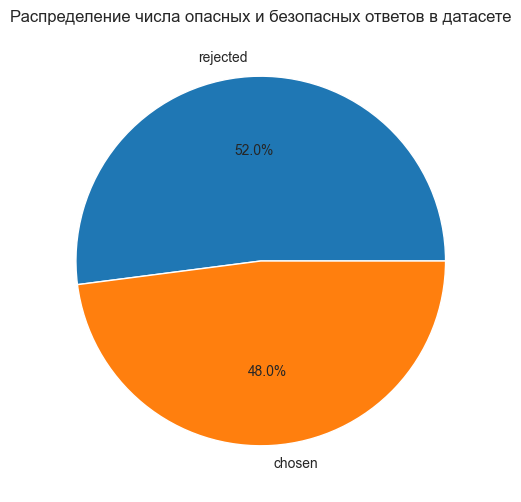

In [9]:
plt.figure(figsize=(12,6))
plt.pie(data_dpo_classifier['is_unsafe_response'].value_counts(),
        labels=['rejected','chosen'],
        autopct='%1.1f%%',
        )
plt.title('Распределение числа опасных и безопасных ответов в датасете',fontsize=12)
plt.show()

In [10]:
data_dpo_classifier.info()

<class 'pandas.DataFrame'>
Index: 18627 entries, 3 to 48023
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   prompt              18627 non-null  str  
 1   is_unsafe_prompt    18627 non-null  int64
 2   response            18627 non-null  str  
 3   is_unsafe_response  18627 non-null  int64
 4   from_dataset        18627 non-null  str  
 5   text_length         18627 non-null  int64
 6   word_count          18627 non-null  int64
 7   prompt_len          18627 non-null  int64
 8   prompt_word_count   18627 non-null  int64
dtypes: int64(6), str(3)
memory usage: 20.8 MB


In [11]:
data_dpo_classifier['is_unsafe_response'].value_counts()

is_unsafe_response
1    9694
0    8933
Name: count, dtype: int64

In [12]:
data_dpo_classifier=data_dpo_classifier.groupby('is_unsafe_response').apply(lambda x: x.sample(min(len(x),8000))).reset_index()

In [13]:
data_dpo_classifier.to_csv('data_dpo_classifier.csv')

TRAIN CLASSIFIER

In [14]:
import pandas as pd
import numpy as np
from prompts_classifier import split_data,tokenize_function,compute_metrics
from transformers import AutoTokenizer,AutoModelForSequenceClassification,Trainer,TrainingArguments,DataCollatorWithPadding, DistilBertConfig
from dotenv import load_dotenv
load_dotenv()

C:\Users\vpooz\PycharmProjects\LLM Security Scaner\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [15]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="torch")

In [16]:
train_data,val_data,test_data=split_data(data,text_column='response',label_column='is_unsafe_response')

In [17]:

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
train_data=train_data.map(lambda x: tokenize_function(x,tokenizer),batched=True)
val_data=val_data.map(lambda x: tokenize_function(x,tokenizer),batched=True)
test_data=test_data.map(lambda x: tokenize_function(x,tokenizer),batched=True)

Map: 100%|██████████| 5254/5254 [00:00<00:00, 5694.15 examples/s]


In [18]:
model=AutoModelForSequenceClassification.from_pretrained('bert-base-uncased')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 374.24it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

In [19]:

training_args=TrainingArguments(
    output_dir='/.response_classifier_results',

    num_train_epochs=3,
    warmup_ratio=0.1,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    learning_rate=2e-5,
    weight_decay=0.05,
    max_grad_norm=0.5,


    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,

    logging_steps=100,

    save_total_limit=2,
    seed=17
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [20]:

data_collator=DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,

    data_collator=data_collator,
    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

In [ ]:
trainer.evaluate(test_data)

In [ ]:
trainer.model.save_pretrained('/.dpo_response_classifier')
tokenizer.save_pretrained('/.dpo_response_classifier')